In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, uniform, norm
from astroML import stats as astroMLstats
from sklearn.neighbors import KernelDensity

In [29]:
N = 1000 #number of measurements of mass and spin

mu = 1
sigma = 0.02

spin = uniform.rvs(loc=0, scale=1, size=N)
M = norm.rvs(loc=mu, scale=sigma, size=N)

In [8]:
def M_irr(m, chi):
    mirr = m * np.sqrt((1 + np.sqrt(1 - spin**2)) / 2)
    return mirr

In [9]:
def f(mirr, m):
    return mirr / m

(array([  5.,   3.,   5.,   7.,  13.,  17.,  17.,  23.,  36.,  32.,  46.,
         57.,  59.,  66., 100., 143., 146., 116.,  74.,  30.,   5.]),
 array([0.71187302, 0.72830768, 0.74474235, 0.76117701, 0.77761167,
        0.79404634, 0.810481  , 0.82691566, 0.84335033, 0.85978499,
        0.87621965, 0.89265432, 0.90908898, 0.92552364, 0.94195831,
        0.95839297, 0.97482763, 0.9912623 , 1.00769696, 1.02413162,
        1.04056629, 1.04972255]),
 <BarContainer object of 21 artists>)

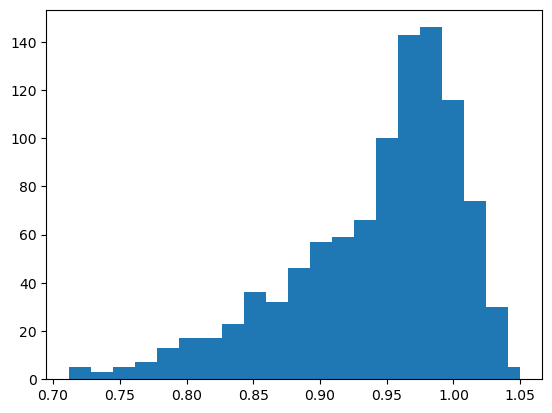

In [30]:
mirr = M_irr(M, spin)

#bins made with Freedman-Diaconis
sigmaG2 = astroMLstats.sigmaG(mirr)
bin_width = 2.7*sigmaG2/(N**(1/3))
binsG = np.append(np.arange(start=mirr.min(), stop=mirr.max(), step=bin_width) , mirr.max())

fig, ax = plt.subplots()
plt.hist(mirr, bins=binsG)

In [31]:
# now using a kde

xgrid = np.linspace(mirr.min(), mirr.max(), 1000)

def kde_sklearn(data, bandwidth = 1.0, kernel="gaussian"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

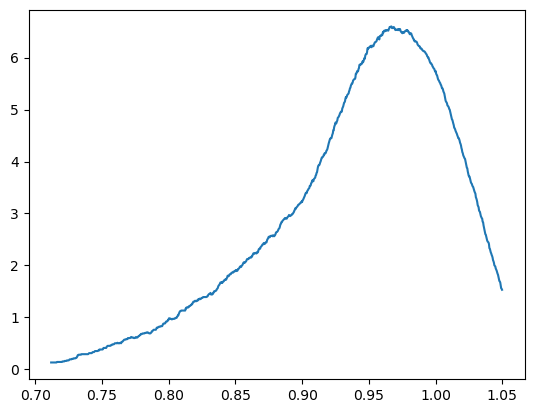

In [32]:
PDFtophat = kde_sklearn(mirr, bandwidth=0.05, kernel="tophat") 
plt.plot(xgrid,PDFtophat)

In [45]:
# KS distance between Mirr/mu and f as a function of sigma

sigma_arr = np.linspace(0.01, 10, 100000)
dist_results = []


for i in range(100000):
    spin = uniform.rvs(loc=0, scale=1, size=N)
    M = norm.rvs(loc=mu, scale=sigma_arr[i], size=N)

    mirr = M_irr(M, spin)
    f_vals = f(mirr, M)

    ks = ks_2samp(mirr, f_vals)

    ksdist = ks.statistic
    dist_results.append(ksdist)

Text(0, 0.5, 'KS')

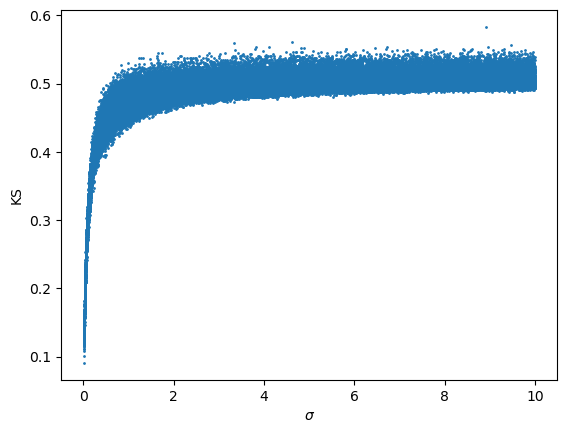

In [46]:
fig, ax = plt.subplots()
plt.scatter(sigma_arr, dist_results, s=1, marker='o')
plt.xlabel(r'$\sigma$')
plt.ylabel('KS')